In [1]:
import os, re, glob,calendar

import pandas as pd
import numpy as np
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mc
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick

from datetime import datetime, timedelta

plt.rcParams['legend.handlelength'] = 1
plt.rcParams['legend.handleheight'] = 1.125
plt.rcParams["font.family"]         = ["Montserrat", "DejaVu Sans"]

path_to_csv_files = '/home/abhis/india_power/gridpath_india_viz/csvs'
path_to_inputs    = '/home/abhis/india_power/gridpath_india_viz/cost_dfs_for_plots'
path_to_images    = '/home/gterren/india_power/images/'

df_fixed_cost = pd.read_csv(os.path.join(path_to_inputs, 'fixed_cost_2040.csv'))
df_demand = pd.read_csv(os.path.join(path_to_inputs, 'demand_2040.csv'))
df_demand_capex = pd.read_csv(os.path.join(path_to_inputs, 'demand_capex_2040.csv'))

df_metrics = pd.read_csv(os.path.join(path_to_inputs, 'lolp_results.csv'))
df_variable_cost = pd.read_csv(os.path.join(path_to_inputs, 'variable_cost.csv'))
df_fixed_cost_all_periods = pd.read_csv(os.path.join(path_to_inputs, 'fixed_costs_all_periods.csv'))

ra_labels = pd.read_csv(os.path.join(path_to_csv_files, 'ra-cost_scenario_labels.csv'))
capex_labels = pd.read_csv(os.path.join(path_to_csv_files, 'capex-scenario_labels.csv'))
lolp_labels = pd.read_csv(os.path.join(path_to_csv_files, 'ra_scen_labels_for_lolp.csv'))

voll_cea = 140 # Rs/kWh

In [2]:
lables=pd.merge(ra_labels, capex_labels, on='scenario', how='left')

In [3]:
df_variable_cost_national= df_variable_cost.groupby(['scenario','iteration']).sum().reset_index()
df_variable_cost_national=df_variable_cost_national[['scenario','iteration','variable_cost']]
df_variable_cost_national=pd.merge( df_variable_cost_national,ra_labels, on='scenario', how='left')
df_variable_cost_national=df_variable_cost_national[['scenario','iteration','variable_cost','label']]


df_demand_national=df_demand_capex.copy()
df_demand_national=pd.merge( df_demand_national,capex_labels, on='scenario', how='left')

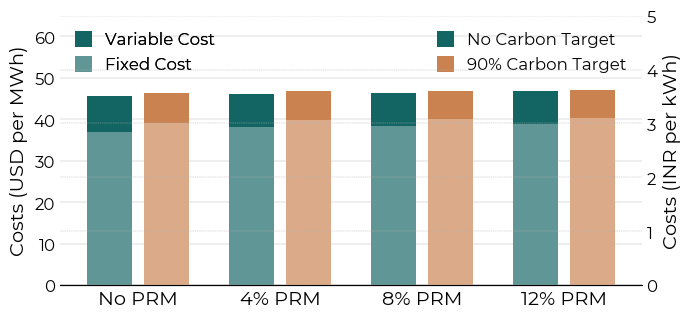

<Figure size 640x480 with 0 Axes>

In [4]:
def lighten_hex(hex_color, amount=0.5):
    r, g, b = mc.to_rgb(hex_color)
    return (
        r + (1 - r) * amount,
        g + (1 - g) * amount,
        b + (1 - b) * amount
    )

def _plot_stacked_cost(ax, df_variable_cost_national, df_fixed_cost, bar_colors,
                      fixed_col='total_fixed_cost',
                      var_col='variable_cost',
                      label_col='label',
                      order_col='order',
                      width=0.1):

    # --- Mean variable cost per label ---
    df_var_mean = (
        df_variable_cost_national.groupby(label_col)[var_col]
        .mean().reset_index()
    )

    # Merge fixed + mean variable cost
    df_costs = pd.merge(
        df_fixed_cost[[label_col, fixed_col, order_col]],
        df_var_mean,
        on=label_col, how='outer'
    ).sort_values(order_col).reset_index(drop=True)

    df_costs['total_fixed_cost'] = df_costs['total_fixed_cost'] / df_demand_national['load_mw'].mean()
    df_costs['variable_cost']    = df_costs['variable_cost']    / df_demand_national['load_mw'].mean()

    labels        = df_costs[label_col].values
    fixed_cost    = df_costs[fixed_col].values
    var_cost_mean = df_costs[var_col].values

    gap = 0.5
    n = len(labels)
    x = np.arange(n) + (np.arange(n)//2)*gap

    fixed_bar_colors = [lighten_hex(c, amount=0.325)for c in bar_colors]
    # ------------------------------------------------------------

    ax.bar(x, fixed_cost, color=fixed_bar_colors, label='Fixed Cost', zorder=4)
    ax.bar(x, var_cost_mean, bottom=fixed_cost, color=bar_colors, label='Variable Cost', zorder = 4)
    xp = (x[1::2] + x[::2])/2
    ax.set_xticks(xp)
    ax.set_xticklabels(['No PRM', 
                        '4% PRM', 
                        '8% PRM',
                        '12% PRM'], rotation=0, ha='center', fontsize=14)
    ax.tick_params(axis="x", length=0)

    ax.set_ylabel("Costs (USD per MWh)", fontsize=14)
    ax.tick_params(axis='y', labelsize=12, length=0)

    ax2 = ax.twinx()

    to_inr_kwh = lambda usd_mwh: usd_mwh * 72 / 1000

    ax.set_ylim(0, 65)

    y0, y1 = ax.get_ylim()
    ax2.set_ylim(to_inr_kwh(y0), to_inr_kwh(y1))

    y2_min, y2_max = ax2.get_ylim()
    ax2.set_yticks(np.arange(np.floor(y2_min), np.ceil(y2_max)+1, 1))

    ax2.set_ylabel("Costs (INR per kWh)", fontsize=14)
    ax2.tick_params(axis='y', labelsize=12, length=0)

    # ax.legend(loc='center left', bbox_to_anchor=(1.05,1.0), fontsize=12)

    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    ax2.spines['bottom'].set_visible(True)
    ax2.spines['left'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['top'].set_visible(False)

    ax.grid(axis='y', lw=.3, zorder=3)
    ax.set_axisbelow(True)

    ax2.grid(axis='y', lw=.3, linestyle='--', zorder=3)
    ax2.set_axisbelow(True)

    handles = [
        mpatches.Patch(facecolor=bar_colors[0], edgecolor="none", label="No Carbon Target"),
        mpatches.Patch(facecolor=bar_colors[1], edgecolor="none", label="90% Carbon Target"),
    ]

    leg1 = ax.legend(handles=handles, loc="upper right", frameon=False, fontsize = 12)

    ax.add_artist(leg1)

    # Legend 2 (e.g., groups/colors as squares)
    handles2 = [
        mpatches.Patch(facecolor="#136564", label="Variable Cost"),
        mpatches.Patch(facecolor=lighten_hex("#136564", amount=0.325), label="Fixed Cost"),
    ]
    leg2 = ax.legend(handles=handles2, loc="upper left", frameon=False, fontsize = 12)

    # Keep both legends
    ax.add_artist(leg2)


    plt.show()

# '#ca8250', "#2cb7b5", '#900C3F', "#92918b", '#136564', '#756a01'
bar_colors = ["#136564",
              '#ca8250',
              "#136564",
              '#ca8250', 
              "#136564",
              '#ca8250']

fig, ax = plt.subplots(figsize=(7.5, 3.5))

_plot_stacked_cost(ax, df_variable_cost_national, df_fixed_cost, bar_colors)

plt.savefig(path_to_images + '/fix_and_variable_cost.png', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.tight_layout()
plt.show()

# cost vs USE plot

In [5]:
df_var_cost_label_wise = df_variable_cost_national.groupby('label')['variable_cost'].mean().reset_index()

# assign lolp labels to df_metrics
df_metrics_lolp = pd.merge(df_metrics, lolp_labels, on='scenario', how='left')

# merge df_metrics_lolp df_var_cost_label_wise and df_fixed_cost to get total cost vs lolp plot
df_total_cost_lolp = pd.merge(df_metrics_lolp, df_var_cost_label_wise, on='label', how='left')
df_total_cost_lolp = pd.merge(df_total_cost_lolp, df_fixed_cost[['label','total_fixed_cost']], on='label', how='left')  
df_total_cost_lolp['total_cost'] = df_total_cost_lolp['variable_cost'] + df_total_cost_lolp['total_fixed_cost']


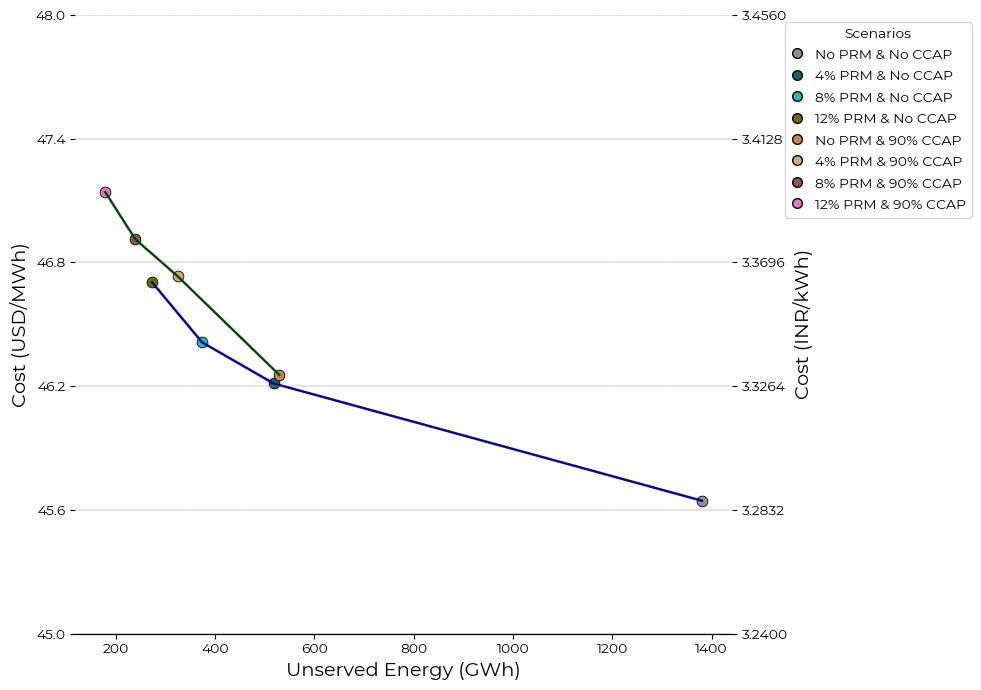

In [6]:
def _plot_cost_vs_unserved_connected_dual_axis(ax, df, 
                                              cost_col='total_cost', 
                                              ue_col='total_unserved_energy_mwh',
                                              label_col='label'):

    # Clean labels (remove double spaces, trailing spaces)
    normalize = lambda s: re.sub(r'\s+', ' ', s).strip()
    df = df.copy()
    df['label_clean'] = df[label_col].apply(normalize)

    # Ordered scenarios (cleaned)
    order_no_ccap = [
        "No PRM & No CCAP",
        "4% PRM & No CCAP",
        "8% PRM & No CCAP",
        "12% PRM & No CCAP"
    ]

    order_90_ccap = [
        "No PRM & 90% CCAP",
        "4% PRM & 90% CCAP",
        "8% PRM & 90% CCAP",
        "12% PRM & 90% CCAP"
    ]

    groups = {
        "No CCAP": order_no_ccap,
        "90% CCAP": order_90_ccap
    }

    # ------------------------------------------------------------
    # MANUAL COLORS — SAME ORDER AS YOUR STACKED PLOT
    # ------------------------------------------------------------
    all_labels = order_no_ccap + order_90_ccap

    manual_colors = [
        "#92918b",
        "#136564",
        "#2cb7b5",
        "#756a01",
        "#ca8250",
        "#d8a581",
        "#8c564b",
        "#e377c2",
        "#7f7f7f",
    ]

    color_map = {lab: manual_colors[i] for i, lab in enumerate(all_labels)}
    # ------------------------------------------------------------

    # Plot each grouping as a connected line
    for group_name, ordered_list in groups.items():

        df_g = df[df['label_clean'].isin(ordered_list)].copy()
        df_g['label_clean'] = pd.Categorical(df_g['label_clean'],
                                             categories=ordered_list,
                                             ordered=True)
        df_g = df_g.sort_values('label_clean')

        # X (Unserved Energy → GWh over 18 years)
        x = df_g[ue_col] / (1e3 * 18)

        # Y (Cost → USD/MWh)
        y_usd = df_g[cost_col] / df_demand_national['load_mw'].mean()

        # --------------------------------------------
# SET LINE COLORS FOR EACH GROUP
        # --------------------------------------------
        if group_name == "No CCAP":
            line_color = "blue"      # Line 1
        elif group_name == "90% CCAP":
            line_color = "green"     # Line 2
        else:
            line_color = "black"     # fallback (not used)

        ax.plot(x, y_usd, color=line_color, linewidth=1.8, alpha=0.9)
# --------------------------------------------


        # Connected line
        ax.plot(x, y_usd, color='black', linewidth=1.2, alpha=0.6)

        # Scatter points
        for _, row in df_g.iterrows():
            lab = row['label_clean']
            ax.scatter(
                row[ue_col] / (1e3 * 18),
                row[cost_col] / df_demand_national['load_mw'].mean(),
                color=color_map[lab],
                s=60,
                edgecolor='black',
                linewidth=0.6
            )

    # ------------------------------------------------
    # SECONDARY Y AXIS (INR/kWh)
    # ------------------------------------------------
    ax2 = ax.twinx()

    to_inr_kwh = lambda usd_mwh: usd_mwh * 72 / 1000
    to_usd_mwh = lambda inr_kwh: inr_kwh * 1000 / 72

    # Compute USD limits first
    y0, y1 = ax.get_ylim()

    # --------- UNIFORM TICKS ON BOTH AXES ----------
    left_ticks = np.linspace(y0, y1, 6)
    ax.set_yticks(left_ticks)

    right_ticks = to_inr_kwh(left_ticks)
    ax2.set_yticks(right_ticks)

    ax2.set_ylim(right_ticks[0], right_ticks[-1])

    # -----------------------------------------------
    # LABELS
    # -----------------------------------------------
    ax.set_xlabel("Unserved Energy (GWh)", fontsize=14)
    ax.set_ylabel("Cost (USD/MWh)", fontsize=14)
    ax2.set_ylabel("Cost (INR/kWh)", fontsize=14)


        # ------------------------------------------------
    # FIX LEFT Y-AXIS RANGE (USD/MWh)
    # ------------------------------------------------
    ax.set_ylim(45, 48)

    # Recompute y-limits for secondary axis
    y0, y1 = ax.get_ylim()
    left_ticks = np.linspace(y0, y1, 6)
    ax.set_yticks(left_ticks)
    right_ticks = to_inr_kwh(left_ticks)
    ax2.set_yticks(right_ticks)
    ax2.set_ylim(right_ticks[0], right_ticks[-1])


    # -----------------------------------------------
    # VISUAL STYLE MATCHING stacked plot
    # -----------------------------------------------
    ax.spines['bottom'].set_visible(True)
    for s in ['left', 'right', 'top']:
        ax.spines[s].set_visible(False)

    ax2.spines['bottom'].set_visible(True)
    for s in ['left', 'right', 'top']:
        ax2.spines[s].set_visible(False)

    # KEEP GRID LINES BEHIND MARKERS
    ax.set_axisbelow(True)
    ax.grid(axis='y', lw=.3, zorder=0)

    ax2.set_axisbelow(True)
    ax2.grid(axis='y', lw=.3, linestyle='--', zorder=0)

    # -----------------------------------------------
    # LEGEND
    # -----------------------------------------------
    legend_handles = []
    for lab in all_labels:
        handle = plt.Line2D(
            [0],[0],
            marker='o',
            linestyle='',
            markersize=7,
            markerfacecolor=color_map[lab],
            markeredgecolor='black'
        )
        legend_handles.append(handle)

    ax.legend(
        legend_handles,
        all_labels,
        title="Scenarios",
        bbox_to_anchor=(1.07, 1),
        loc='upper left',
        fontsize=10
    )

fig, ax = plt.subplots(figsize=(10,7))

_plot_cost_vs_unserved_connected_dual_axis(ax, df_total_cost_lolp,
                                           cost_col='total_cost',
                                           ue_col='total_unserved_energy_mwh',
                                           label_col='label')

plt.savefig(path_to_images + '/fix_and_variable_cost.png', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.tight_layout()
plt.show()

# USE vs PRM

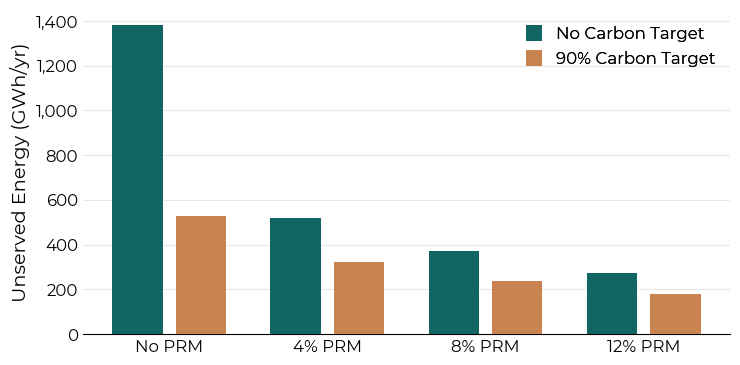

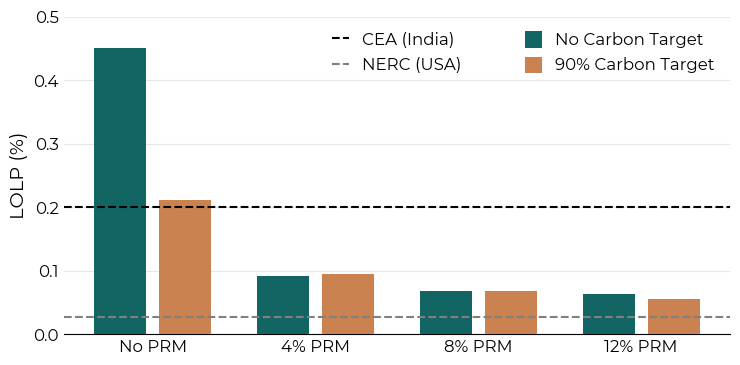

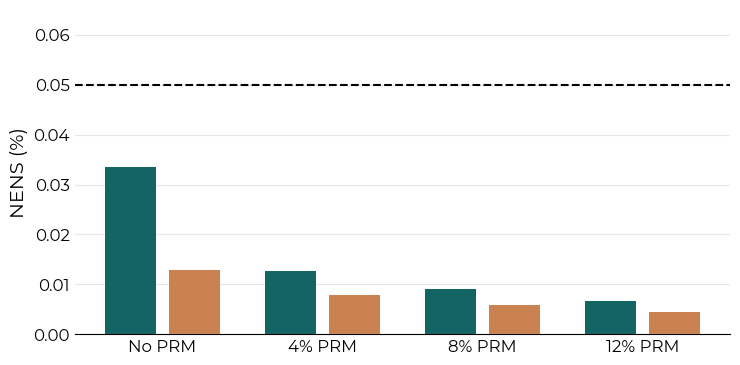

In [81]:
# ---- Manual colors (user-specified) ----
# manual_colors = [
#     "#92918b",
#     "#136564",
#     "#2cb7b5",
#     "#756a01",
#     "#ca8250",
#     "#d8a581",
#     "#8c564b",
#     "#e377c2",
#     "#7f7f7f",
# ]

def _plot_metric(ax, df, manual_colors,
                 units = 1,
                 ylabel = '',
                 metric_col='total_unserved_energy_mwh',
                 label_col='label', legend = True):

    # ---- Preserve original order of labels ----
    original_order = df[label_col].unique()

    # Aggregate (mean across scenarios)
    df_plot = df.groupby(label_col, as_index=False)[metric_col].mean()

    # Convert label column to categorical to preserve the original order
    df_plot[label_col] = pd.Categorical(
        df_plot[label_col],
        categories=original_order,
        ordered=True
    )

    df_plot = df_plot.sort_values(label_col)

    # ---- Ensure enough colors ----
    if len(df_plot) > len(manual_colors):
        raise ValueError("Not enough manual_colors for number of labels")

    bar_colors = manual_colors[:len(df_plot)]

    gap = 0.5
    n = df_plot[label_col].shape[0]
    x = np.arange(n) + (np.arange(n)//2)*gap

    ax.bar(x, df_plot[metric_col] / units,   # MWh → GWh / 18 yrs
           color=bar_colors,
           zorder=3)

    ax.set_ylabel(ylabel, fontsize=14)
    #ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right', fontsize=14)

    xp = (x[1::2] + x[::2])/2
    ax.set_xticks(xp)
    ax.set_xticklabels(['No PRM', 
                        '4% PRM', 
                        '8% PRM',
                        '12% PRM'], rotation=0, ha='center', fontsize=14)
    
    ax.tick_params(axis="y", labelsize=12, length=0)
    ax.tick_params(axis='x', labelsize=12, length=0)


    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)

    ax.grid(axis='y', alpha=0.3)

    if legend:
        handles = [mpatches.Patch(facecolor=bar_colors[0], edgecolor="none", label="No Carbon Target"),
                   mpatches.Patch(facecolor=bar_colors[1], edgecolor="none", label="90% Carbon Target")]

        leg1 = ax.legend(handles=handles, loc="upper right", frameon=False, fontsize = 12)

        ax.add_artist(leg1)

bar_colors = ["#136564",
              '#ca8250',
              "#136564",
              '#ca8250', 
              "#136564",
              '#ca8250',
              "#136564",
              '#ca8250']

fig, ax = plt.subplots(figsize=(7.5, 3.75))

# ---- Call ----
_plot_metric(ax, df_total_cost_lolp, bar_colors,
             metric_col='total_unserved_energy_mwh',
             label_col='label',
             units = (1e3 * 18),
             ylabel = "Unserved Energy (GWh/yr)")

ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.savefig(path_to_images + '/ra-use.png', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 3.75))

# ---- Call ----
_plot_metric(ax, df_total_cost_lolp, bar_colors,
             metric_col='lolp_pct',
             label_col='label',
             ylabel = "LOLP (%)")

ax.axhline(y=.2,
           color="black",
           linestyle="--",
           linewidth=1.5,
           zorder=5, 
           label = 'CEA (India)')

ax.axhline(y=.027,
           color="gray",
           linestyle="--",
           linewidth=1.5,
           zorder = 5, 
           label = 'NERC (USA)')

plt.legend(loc="upper center", frameon=False, fontsize = 12)

ax.set_ylim(0, 0.5)

plt.savefig(path_to_images + '/ra-lolp.png', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 3.75))

# ---- Call ----
_plot_metric(ax, df_total_cost_lolp, bar_colors,
             metric_col='nens_pct',
             label_col='label',
             ylabel = "NENS (%)", legend = False)

ax.axhline(y=.05,
           color="black",
           linestyle="--",
           linewidth=1.5,
           zorder=5, 
           label = 'CEA (India)')

ax.set_ylim(0, 0.065)

#plt.legend(loc="upper center", frameon=False, fontsize = 12)

plt.savefig(path_to_images + '/ra-nens.png', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.tight_layout()
plt.show()


         scenario  lolp_pct  total_unserved_energy_mwh  nens_pct  \
0  no_prm_no_ccap    0.4509               2.484339e+07  0.033596   
1  no_prm_90_ccap    0.2112               9.536188e+06  0.012896   
2   4_prm_no_ccap    0.0913               9.323915e+06  0.012609   
3   4_prm_90_ccap    0.0939               5.843120e+06  0.007902   
4   8_prm_no_ccap    0.0679               6.730042e+06  0.009101   
5   8_prm_90_ccap    0.0679               4.310689e+06  0.005829   
6  12_prm_no_ccap    0.0634               4.918632e+06  0.006651   
7  12_prm_90_ccap    0.0552               3.220869e+06  0.004356   

                label  variable_cost  total_fixed_cost    total_cost  
0    No PRM & No CCAP   3.620742e+10      1.549960e+11  1.912034e+11  
1   No PRM & 90% CCAP   2.945223e+10      1.643030e+11  1.937552e+11  
2    4% PRM & No CCAP   3.408877e+10      1.594960e+11  1.935848e+11  
3  4% PRM &  90% CCAP   2.903547e+10      1.667280e+11  1.957635e+11  
4    8% PRM & No CCAP   3.367430

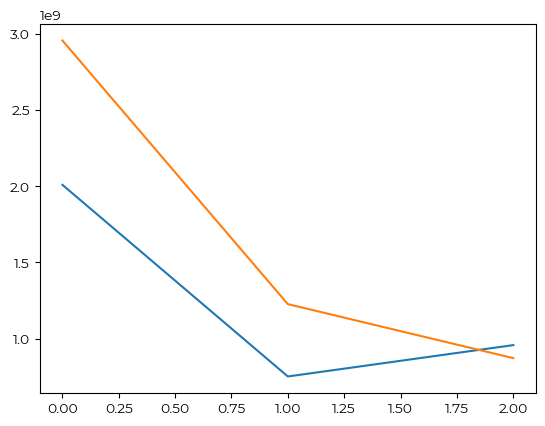

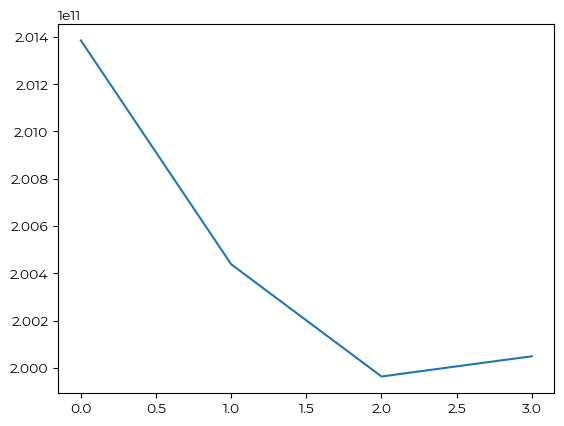

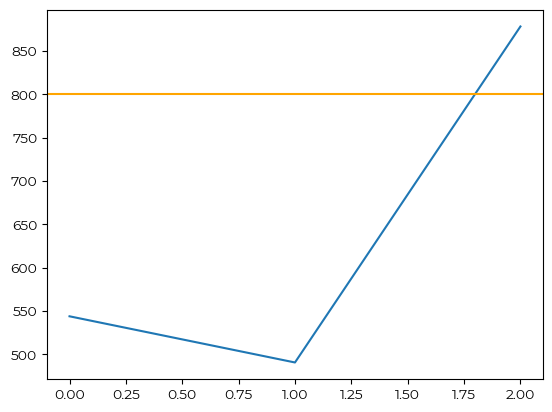

In [ ]:
print(df_total_cost_lolp)

scens_ = ['no_prm_90_ccap', '4_prm_90_ccap', '8_prm_90_ccap', '12_prm_90_ccap']

cost_prm_ = []
use_prm_  = []

for scen in scens_:
    cost_prm_.append(df_total_cost_lolp.loc[df_total_cost_lolp['scenario'] == scen, 'total_cost'].to_numpy()[0])
    use_prm_.append(df_total_cost_lolp.loc[df_total_cost_lolp['scenario'] == scen, 'total_unserved_energy_mwh'].to_numpy()[0])

VOLL = 800

cost_prm_ = np.array(cost_prm_)
use_prm_  = np.array(use_prm_)
TC_       = cost_prm_ + (use_prm_ * VOLL)

plt.figure()
plt.plot(np.diff(cost_prm_))
plt.plot(-VOLL*np.diff(use_prm_))
plt.show()

plt.figure()
plt.plot(TC_)
plt.show()

plt.figure()
plt.plot(-np.diff(cost_prm_)/np.diff(use_prm_))
plt.axhline(VOLL, color = 'orange')
plt.show()

#plt.plot((cost_prm_ - cost_prm_[0])/(use_prm_[0] - use_prm_))


[24843386.78   9323915.001  6730041.511  4918631.507]
[       0.    15519471.779 18113345.269 19924755.273]
[9536188.089 5843120.101 4310689.291 3220869.139]
[      0.    3693067.988 5225498.798 6315318.95 ]


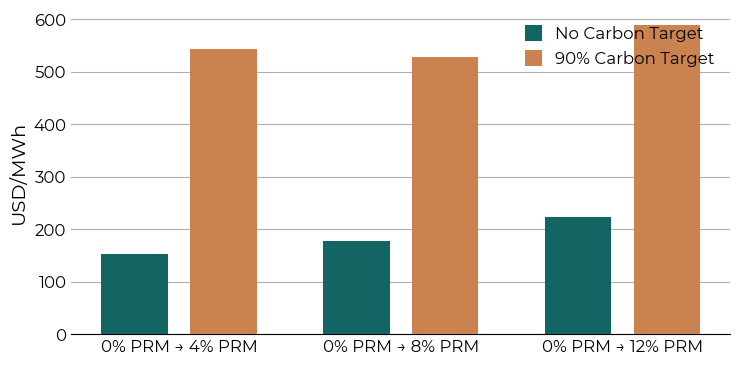

In [85]:
def _plot_cost_of_avoided_use_grouped(ax, df, labels_1_, labels_2_):
    """
    Grouped plot:
    - No CCAP
    - 90% CCAP
    Output units: USD per GWh avoided
    """

    cost_prm_1_ = []
    use_prm_1_  = []
    for label in labels_1_:
        cost_prm_1_.append(df.loc[df['label'] == label, 'total_cost'].to_numpy()[0])
        use_prm_1_.append(df.loc[df['label'] == label, 'total_unserved_energy_mwh'].to_numpy()[0])
    cost_prm_1_  = np.array(cost_prm_1_)
    use_prm_1_   = np.array(use_prm_1_)
    cost_prm_1_ -= cost_prm_1_[0]
    print(use_prm_1_)
    use_prm_1_   = use_prm_1_[0] - use_prm_1_
    print(use_prm_1_)
    
    cost_prm_2_ = []
    use_prm_2_  = []
    for label in labels_2_:
        cost_prm_2_.append(df.loc[df['label'] == label, 'total_cost'].to_numpy()[0])
        use_prm_2_.append(df.loc[df['label'] == label, 'total_unserved_energy_mwh'].to_numpy()[0])

    cost_prm_2_  = np.array(cost_prm_2_)
    use_prm_2_   = np.array(use_prm_2_)
    cost_prm_2_ -= cost_prm_2_[0]
    print(use_prm_2_)
    use_prm_2_   = use_prm_2_[0] - use_prm_2_
    print(use_prm_2_)

    x_labels = ["0% PRM → 4% PRM",
                "0% PRM → 8% PRM",
                "0% PRM → 12% PRM"]  
    
    # -----------------------------
    # Plot
    # -----------------------------

    width = 0.3
    gap = 0.4
    n = len(x_labels)
    x1 = np.arange(n)# + (np.arange(n)//2)*gap
    x2 = x1 + gap

    ax.bar(x1, cost_prm_1_[1:]/use_prm_1_[1:], width,
           label='No Carbon Target',
           color="#136564",
           edgecolor='None',
           zorder=3)

    ax.bar(x2, cost_prm_2_[1:]/use_prm_2_[1:], width,
           label='90% Carbon Target',
           color='#ca8250',
           edgecolor='None',
           zorder=3)

    xp = (x1 + x2)/2
    ax.set_xticks(xp)
    ax.set_xticklabels(x_labels, rotation=0, ha='center', fontsize=14)
    
    ax.set_ylabel("USD/MWh", fontsize=14)

    ax.tick_params(axis="y", labelsize=12, length=0)
    ax.tick_params(axis='x', labelsize=12, length=0)

    ax.grid(axis='y')

    ax = plt.gca()
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)

    ax.tick_params(axis='y', length=0)

    # VOLL line
    #ax.axhline(2000, color='k', linestyle='--', linewidth=1.5, zorder=2)
    #ax.set_ylim(0, 2500)

    # ax.text(0.99, 2000, "Value of Lost Load$^{1}$",
    #         color='k', 
    #         fontsize=12,
    #         ha='right', 
    #         va='bottom',
    #         transform=ax.get_yaxis_transform())

    ax.legend(frameon=False, fontsize=12)

    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))


labels_1_ = ["No PRM & No CCAP",
             "4% PRM & No CCAP",
             "8% PRM & No CCAP",
             "12% PRM & No CCAP"]

labels_2_ = ["No PRM & 90% CCAP",
             "4% PRM &  90% CCAP",
             "8% PRM & 90% CCAP",
             "12% PRM & 90% CCAP"]

fig, ax = plt.subplots(figsize=(7.5, 3.75))

_plot_cost_of_avoided_use_grouped(ax, df_total_cost_lolp, labels_1_, labels_2_)

plt.tight_layout()
plt.show()

In [ ]:
def plot_cost_of_avoided_use_grouped_policy_stairs(df, figsize=(7,6)):
    import numpy as np
    import matplotlib.pyplot as plt
    import pandas as pd
    import re
    from matplotlib.patches import Patch

    # -----------------------------
    # Clean labels
    # -----------------------------
    norm = lambda s: re.sub(r'\s+', ' ', s).strip()
    df = df.copy()
    df['label_clean'] = df['label'].apply(norm)

    order_no_ccap = [
        "No PRM & No CCAP",
        "4% PRM & No CCAP",
        "8% PRM & No CCAP",
        "12% PRM & No CCAP"
    ]

    order_90_ccap = [
        "No PRM & 90% CCAP",
        "4% PRM & 90% CCAP",
        "8% PRM & 90% CCAP",
        "12% PRM & 90% CCAP"
    ]

    def compute_marginal_costs(order_list):
        df_g = df[df['label_clean'].isin(order_list)].copy()
        df_g['label_clean'] = pd.Categorical(
            df_g['label_clean'], order_list, ordered=True
        )
        df_g = df_g.sort_values('label_clean')

        cost = df_g['total_cost'].values
        use  = df_g['total_unserved_energy_mwh'].values

        return (cost[1:] - cost[:-1]) / (use[:-1] - use[1:])

    # -----------------------------
    # Marginal costs
    # -----------------------------
    mc_no = compute_marginal_costs(order_no_ccap)   # c1, c2, c3
    mc_90 = compute_marginal_costs(order_90_ccap)

    # cumulative bottoms (stairs)
    bottom_no = np.r_[0, np.cumsum(mc_no[:-1])]
    bottom_90 = np.r_[0, np.cumsum(mc_90[:-1])]

    # -----------------------------
    # X positions (GROUPED BY POLICY)
    # -----------------------------
    x_no  = np.arange(3)          # 0,1,2
    x_90  = np.arange(3) + 4      # 4,5,6 (gap between policies)

    # -----------------------------
    # Plot
    # -----------------------------
    fig, ax = plt.subplots(figsize=figsize)

    # ---- No CCAP stairs ----
    ax.bar(
        x_no,
        mc_no,
        bottom=bottom_no,
        color="#5f5f5f",
        edgecolor="black"
    )

    # ---- 90% CCAP stairs ----
    ax.bar(
        x_90,
        mc_90,
        bottom=bottom_90,
        color="#798A71",
        edgecolor="black"
    )

    # -----------------------------
    # X labels
    # -----------------------------
    ax.set_xticks(list(x_no) + list(x_90))
    ax.set_xticklabels([
        "No PRM → 4% PRM", "No PRM → 8% PRM", "No PRM → 12% PRM",
        "No PRM → 4% PRM", "No PRM → 8% PRM", "No PRM → 12% PRM"
    ], rotation=90)

    # group labels
    # ax.text(1, -0.12, "No CCAP", ha="center", transform=ax.get_xaxis_transform())
    # ax.text(5, -0.12, "90% CCAP", ha="center", transform=ax.get_xaxis_transform())

    # -----------------------------
    # Styling
    # -----------------------------
    ax.set_ylabel("Cost (USD/MWh)")
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.tick_params(axis='y', length=1.5)

    # VOLL reference
    ax.axhline(2000, color='k', linestyle='--', linewidth=1.5)
    ax.text(
        0.99, 2000,
        "Value of Lost Load$^{1}$",
        ha='right', va='bottom',
        transform=ax.get_yaxis_transform(),
        fontsize=12
    )

    # Legend
    legend_handles = [
        Patch(facecolor="#5f5f5f", edgecolor="black", label="No CCAP"),
        Patch(facecolor="#798A71", edgecolor="black", label="90% CCAP")
    ]
    ax.legend(handles=legend_handles, frameon=False)

    plt.tight_layout()
    plt.show()

plot_cost_of_avoided_use_grouped_policy_stairs(df_total_cost_lolp)


In [14]:
# ---- NENS values (in scenario order) ----
nens_values = [
    0.05359,
    0.0431,
    0.0226,
    0.0179,
    0.0091,
    0.0058,
    0.0066,
    0.0043
]

# Add NENS to df_metrics_lolp
df_metrics_lolp = df_metrics_lolp.copy()

# Preserve scenario order
scenario_order = df_metrics_lolp['label'].unique()

nens_df = pd.DataFrame({
    'label': scenario_order,
    'nens_pct': nens_values
})

df_metrics_lolp = pd.merge(
    df_metrics_lolp,
    nens_df,
    on='label',
    how='left'
)


In [ ]:
manual_colors = [
    "#92918b",
    "#136564",
    "#2cb7b5",
    "#756a01",
    "#ca8250",
    "#d8a581",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
]

def plot_nens_by_scenario(ax, df,
                          nens_col='nens_pct',
                          label_col='label'):

    # Preserve scenario order
    original_order = df[label_col].unique()
    print(df)
    df_plot = df.groupby(label_col, as_index=False)[nens_col].mean()

    df_plot[label_col] = pd.Categorical(
        df_plot[label_col],
        categories=original_order,
        ordered=True
    )
    df_plot = df_plot.sort_values(label_col)

    # Ensure enough colors
    if len(df_plot) > len(manual_colors):
        raise ValueError("Not enough colors in manual_colors for scenarios")

    bar_colors = manual_colors[:len(df_plot)]


    ax.bar(
        df_plot[label_col],
        df_plot[nens_col],
        color=bar_colors,
        edgecolor="black",
        linewidth=0.6,
        zorder=3
    )

    ax.set_ylabel("NENS (%)")
    ax.set_xticklabels(
        df_plot[label_col],
        rotation=90,
        ha='right'
    )

    ax.tick_params(axis='both', labelsize=14, length=0)
    ax.axhline(0.05, color='black', linestyle=':', linewidth=1.5, zorder=4)
    ax.set_ylim(0, 0.06)


    # ---- Style ----
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)

    ax.grid(axis='y', alpha=0.3, zorder=0)
    ax.set_axisbelow(True)

# ---- Plot ----
fig, ax = plt.subplots(figsize=(10,7))

plot_nens_by_scenario(ax, df_metrics_lolp,
    nens_col='nens_pct_x',
    label_col='label')

plt.tight_layout()
plt.show()


         scenario  lolp_pct  total_unserved_energy_mwh  nens_pct_x  \
0  no_prm_no_ccap    0.4509               2.484339e+07    0.033596   
1  no_prm_90_ccap    0.2112               9.536188e+06    0.012896   
2   4_prm_no_ccap    0.0913               9.323915e+06    0.012609   
3   4_prm_90_ccap    0.0939               5.843120e+06    0.007902   
4   8_prm_no_ccap    0.0679               6.730042e+06    0.009101   
5   8_prm_90_ccap    0.0679               4.310689e+06    0.005829   
6  12_prm_no_ccap    0.0634               4.918632e+06    0.006651   
7  12_prm_90_ccap    0.0552               3.220869e+06    0.004356   

                label  nens_pct_y  
0    No PRM & No CCAP     0.05359  
1   No PRM & 90% CCAP     0.04310  
2    4% PRM & No CCAP     0.02260  
3  4% PRM &  90% CCAP     0.01790  
4    8% PRM & No CCAP     0.00910  
5   8% PRM & 90% CCAP     0.00580  
6   12% PRM & No CCAP     0.00660  
7  12% PRM & 90% CCAP     0.00430  


/tmp/ipykernel_408237/1853099673.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


<Figure size 640x480 with 0 Axes>